# MetroGuard Insight: Compressor Telemetry Analysis

This notebook explores telemetry data from a metro train compressor. The first part focuses on loading the raw dataset, checking its structure, validating missing values, reviewing the time range, and creating a lighter one-minute dataset for later analysis.

## 1. Setup

We import the basic libraries and local helper functions from the `src/` folder.

In [14]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append("..")

from src.data_processing import (
    ANALOG_SENSOR_COLUMNS,
    DIGITAL_SENSOR_COLUMNS,
    SENSOR_COLUMNS,
    aggregate_to_minutes,
    load_raw_data,
    prepare_telemetry_data,
)
from src.failure_labels import (
    FAILURE_WINDOWS,
    add_failure_labels,
    summarize_operating_states,
)
from src.visualization import (
    plot_correlation_heatmap,
    plot_multiple_sensors_over_time,
    plot_sensor_distributions,
    plot_sensor_over_time,
    plot_sensor_with_failure_windows,
    plot_sensor_state_means,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

DATA_PATH = Path("../data/MetroPT3.csv")
FIGURES_DIR = Path("../outputs/figures")
REPORTS_DIR = Path("../outputs/reports")

## 2. Load Raw Data

The raw file is loaded from `data/MetroPT3.csv`. This file is ignored by Git because it is large and should not be committed to GitHub.

In [15]:
raw_data = load_raw_data(DATA_PATH)

print(f"Rows: {raw_data.shape[0]:,}")
print(f"Columns: {raw_data.shape[1]}")

raw_data.head()

Rows: 1,516,948
Columns: 17


,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## 3. Basic Dataset Information

Before modeling or visualization, we inspect column names, data types, and the first few records. The raw CSV contains an `Unnamed: 0` column, which is only a saved index and will be removed during cleaning.

In [16]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1516948 entries, 0 to 1516947
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Unnamed: 0       1516948 non-null  int64  
 1   timestamp        1516948 non-null  str    
 2   TP2              1516948 non-null  float64
 3   TP3              1516948 non-null  float64
 4   H1               1516948 non-null  float64
 5   DV_pressure      1516948 non-null  float64
 6   Reservoirs       1516948 non-null  float64
 7   Oil_temperature  1516948 non-null  float64
 8   Motor_current    1516948 non-null  float64
 9   COMP             1516948 non-null  float64
 10  DV_eletric       1516948 non-null  float64
 11  Towers           1516948 non-null  float64
 12  MPG              1516948 non-null  float64
 13  LPS              1516948 non-null  float64
 14  Pressure_switch  1516948 non-null  float64
 15  Oil_level        1516948 non-null  float64
 16  Caudal_impulses  1516948 non-

In [17]:
raw_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1516948.0,7.584735e+06,4.379053e+06,0.000,3792367.500,7584735.000,1.137710e+07,1.516947e+07
TP2,1516948.0,1.367826e+00,3.250930e+00,-0.032,-0.014,-0.012,-1.000000e-02,1.067600e+01
TP3,1516948.0,8.984611e+00,6.390951e-01,0.730,8.492,8.960,9.492000e+00,1.030200e+01
H1,1516948.0,7.568155e+00,3.333200e+00,-0.036,8.254,8.784,9.374000e+00,1.028800e+01
DV_pressure,1516948.0,5.595619e-02,3.824015e-01,-0.032,-0.022,-0.020,-1.800000e-02,9.844000e+00
Reservoirs,1516948.0,8.985233e+00,6.383070e-01,0.712,8.494,8.960,9.492000e+00,1.030000e+01
Oil_temperature,1516948.0,6.264418e+01,6.516261e+00,15.400,57.775,62.700,6.725000e+01,8.905000e+01
Motor_current,1516948.0,2.050171e+00,2.302053e+00,0.020,0.040,0.045,3.807500e+00,9.295000e+00
COMP,1516948.0,8.369568e-01,3.694052e-01,0.000,1.000,1.000,1.000000e+00,1.000000e+00
DV_eletric,1516948.0,1.606106e-01,3.671716e-01,0.000,0.000,0.000,0.000000e+00,1.000000e+00


## 4. Clean Data

The cleaning helper removes saved index columns, parses the timestamp, sorts records chronologically, and keeps the 15 expected MetroPT-3 sensor columns.

In [18]:
clean_data = prepare_telemetry_data(raw_data)

print(f"Rows after cleaning: {clean_data.shape[0]:,}")
print(f"Columns after cleaning: {clean_data.shape[1]}")
print(f"Sensor columns: {len(SENSOR_COLUMNS)}")

clean_data.head()

Rows after cleaning: 1,516,948
Columns after cleaning: 16
Sensor columns: 15


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [19]:
clean_data.dtypes

timestamp          datetime64[us]
TP2                       float64
TP3                       float64
H1                        float64
DV_pressure               float64
Reservoirs                float64
Oil_temperature           float64
Motor_current             float64
COMP                      float64
DV_eletric                float64
Towers                    float64
MPG                       float64
LPS                       float64
Pressure_switch           float64
Oil_level                 float64
Caudal_impulses           float64
dtype: object

## 5. Missing Values

Missing values are checked after cleaning. This tells us whether we need imputation or row filtering before analysis.

In [20]:
missing_values = clean_data.isna().sum().reset_index()
missing_values.columns = ["column", "missing_count"]
missing_values["missing_percent"] = (
    missing_values["missing_count"] / len(clean_data) * 100
).round(3)

missing_values

,column,missing_count,missing_percent
0,timestamp,0,0.0
1,TP2,0,0.0
2,TP3,0,0.0
3,H1,0,0.0
4,DV_pressure,0,0.0
5,Reservoirs,0,0.0
6,Oil_temperature,0,0.0
7,Motor_current,0,0.0
8,COMP,0,0.0
9,DV_eletric,0,0.0


In [21]:
total_missing = clean_data.isna().sum().sum()
print(f"Total missing values: {total_missing:,}")

Total missing values: 0


## 6. Time Range and Sampling Interval

Because this is time-series telemetry, we check the full time span and the typical distance between consecutive measurements.

In [22]:
start_time = clean_data["timestamp"].min()
end_time = clean_data["timestamp"].max()
time_span = end_time - start_time

print(f"Start time: {start_time}")
print(f"End time: {end_time}")
print(f"Time span: {time_span.days} days")

Start time: 2020-02-01 00:00:00
End time: 2020-09-01 03:59:50
Time span: 213 days


In [23]:
time_differences = clean_data["timestamp"].diff().dropna().dt.total_seconds()

print(f"Median interval: {time_differences.median()} seconds")
print(f"Duplicate timestamps: {clean_data['timestamp'].duplicated().sum():,}")

time_differences.value_counts().head(10)

Median interval: 10.0 seconds
Duplicate timestamps: 0


timestamp
10.0    1337521
9.0      128277
12.0      38321
13.0       7988
11.0       4471
21.0         10
19.0          5
22.0          4
20.0          3
17.0          3
Name: count, dtype: int64

In [24]:
monthly_counts = clean_data["timestamp"].dt.to_period("M").value_counts().sort_index()
monthly_counts

timestamp
2020-02    214850
2020-03    230448
2020-04    198734
2020-05    212800
2020-06    216514
2020-07    222638
2020-08    220434
2020-09       530
Freq: M, Name: count, dtype: int64

## 7. Aggregate to One-Minute Records

The raw data is quite large, so we aggregate sensor readings into one-minute averages. This keeps the main operating patterns while making the notebook faster and easier to work with.

In [25]:
minute_data = aggregate_to_minutes(clean_data)

print(f"Raw rows: {clean_data.shape[0]:,}")
print(f"One-minute rows: {minute_data.shape[0]:,}")
print(f"Columns: {minute_data.shape[1]}")

minute_data.head()

Raw rows: 1,516,948
One-minute rows: 252,720
Columns: 16


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012286,9.327429,9.311143,-0.022857,9.328000,53.521429,0.040357,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:01:00,-0.013000,9.260000,9.243333,-0.023333,9.259667,53.420833,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:02:00,-0.012667,9.198333,9.182000,-0.022333,9.199000,53.325000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:03:00,-0.012333,9.136667,9.120667,-0.022667,9.136667,53.200000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:04:00,-0.013000,9.075667,9.060000,-0.023000,9.075667,53.129167,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [26]:
minute_data.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,252720,2020-05-17 02:13:11.306980,2020-02-01 00:00:00,2020-03-23 12:45:45,2020-05-18 05:59:30,2020-07-09 18:13:15,2020-09-01 03:59:00,NaN
TP2,252720.0,1.380883,-0.025667,-0.013667,-0.011714,-0.009667,10.497,3.071921
TP3,252720.0,8.980921,0.808,8.489667,8.953667,9.489333,10.252,0.636688
H1,252720.0,7.55133,-0.026,8.229667,8.739333,9.329,10.192,3.16996
DV_pressure,252720.0,0.05539,-0.031333,-0.022333,-0.02,-0.017333,3.526,0.357879
Reservoirs,252720.0,8.981541,0.790667,8.491,8.954667,9.489357,10.253667,0.635934
Oil_temperature,252720.0,62.642955,15.4,57.775,62.779167,67.2125,88.795833,6.500479
Motor_current,252720.0,2.0562,0.02,0.041071,0.045,3.79875,6.363333,2.233016
COMP,252720.0,0.834385,0.0,1.0,1.0,1.0,1.0,0.347161
DV_eletric,252720.0,0.162655,0.0,0.0,0.0,0.0,1.0,0.345355


## 8. Exploratory Data Analysis

This section visualizes the main compressor telemetry signals using the one-minute dataset.

In [27]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

eda_plot_data = minute_data.iloc[::10].copy()

print(f"Rows used for timeline plots: {eda_plot_data.shape[0]:,}")

Rows used for timeline plots: 25,272


### Oil Temperature Over Time

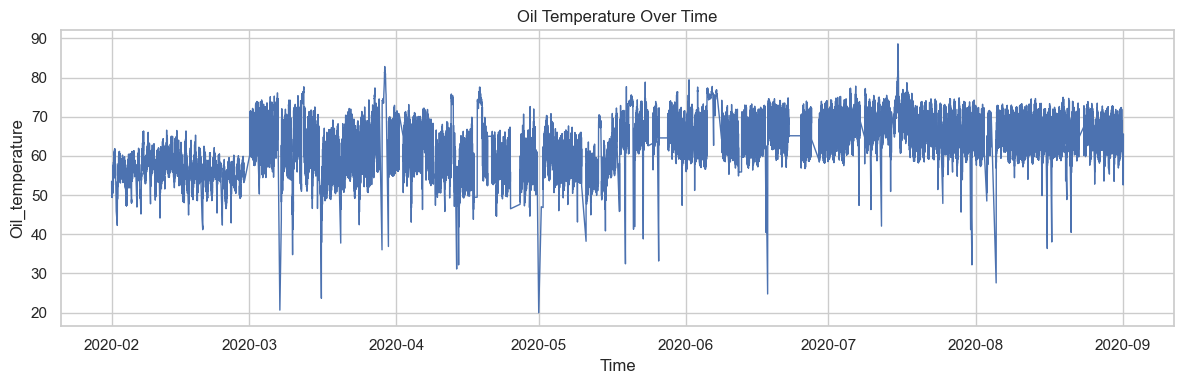

In [28]:
plot_sensor_over_time(
    data=eda_plot_data,
    timestamp_column="timestamp",
    sensor_column="Oil_temperature",
    title="Oil Temperature Over Time",
    output_path=FIGURES_DIR / "oil_temperature_over_time.png",
)

### Motor Current Over Time

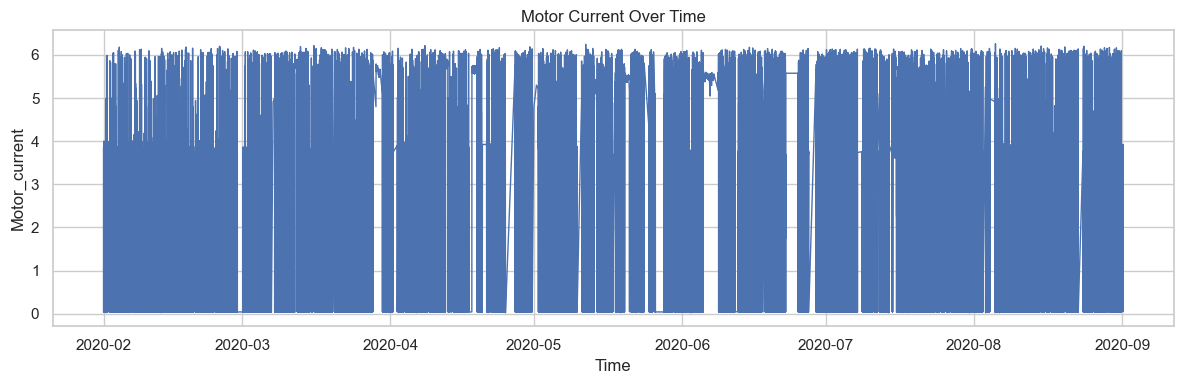

In [29]:
plot_sensor_over_time(
    data=eda_plot_data,
    timestamp_column="timestamp",
    sensor_column="Motor_current",
    title="Motor Current Over Time",
    output_path=FIGURES_DIR / "motor_current_over_time.png",
)

### Pressure-Related Sensor Trends

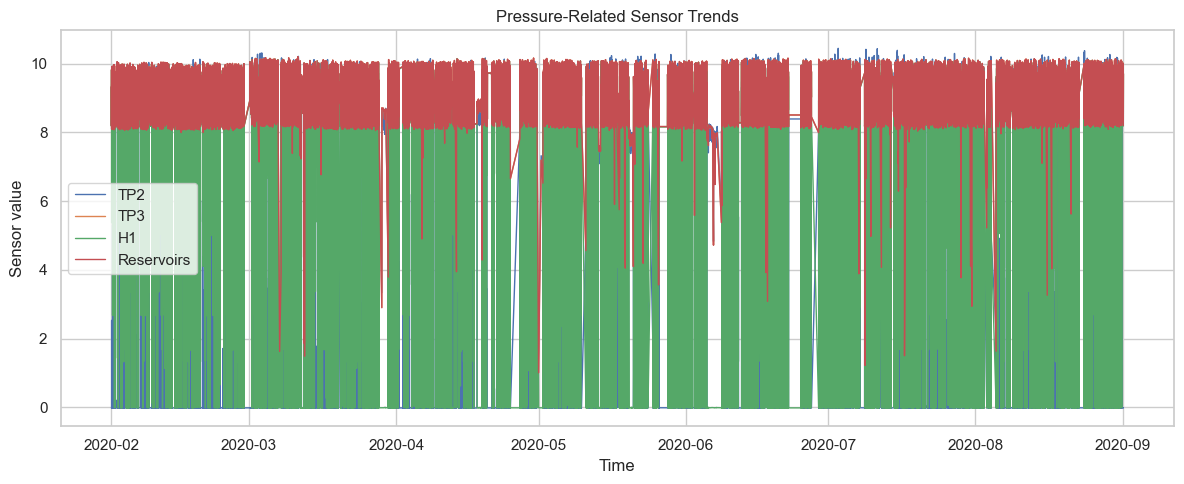

In [30]:
pressure_columns = ["TP2", "TP3", "H1", "Reservoirs"]

plot_multiple_sensors_over_time(
    data=eda_plot_data,
    timestamp_column="timestamp",
    sensor_columns=pressure_columns,
    title="Pressure-Related Sensor Trends",
    output_path=FIGURES_DIR / "sensor_trends.png",
)

### Correlation Heatmap

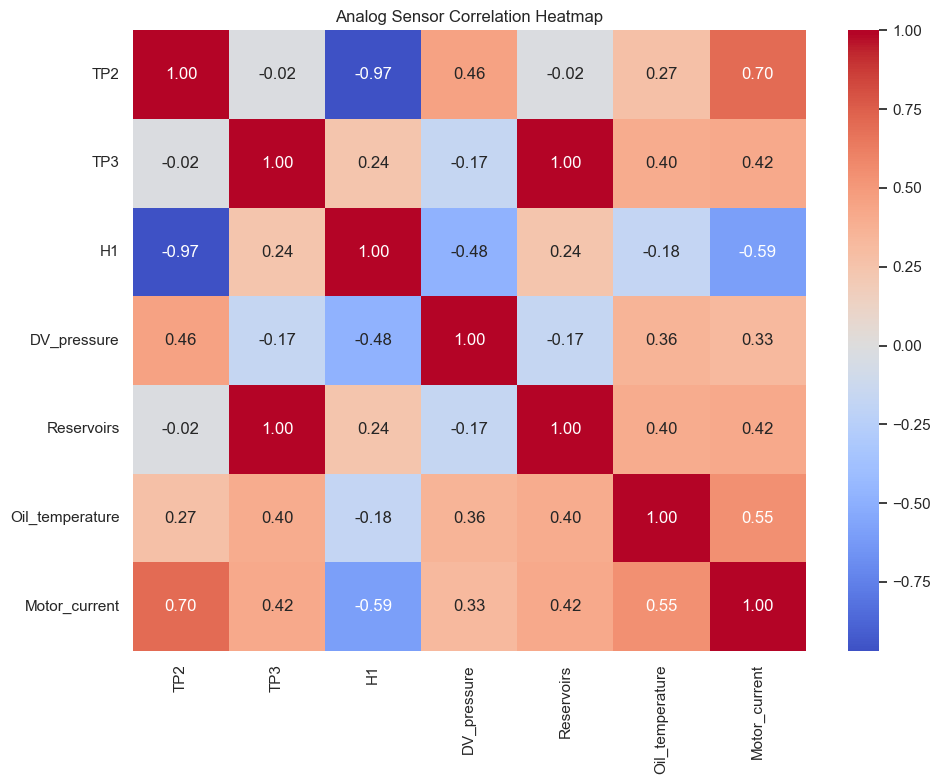

In [31]:
plot_correlation_heatmap(
    data=minute_data,
    sensor_columns=ANALOG_SENSOR_COLUMNS,
    title="Analog Sensor Correlation Heatmap",
    output_path=FIGURES_DIR / "correlation_heatmap.png",
)

### Sensor Distributions

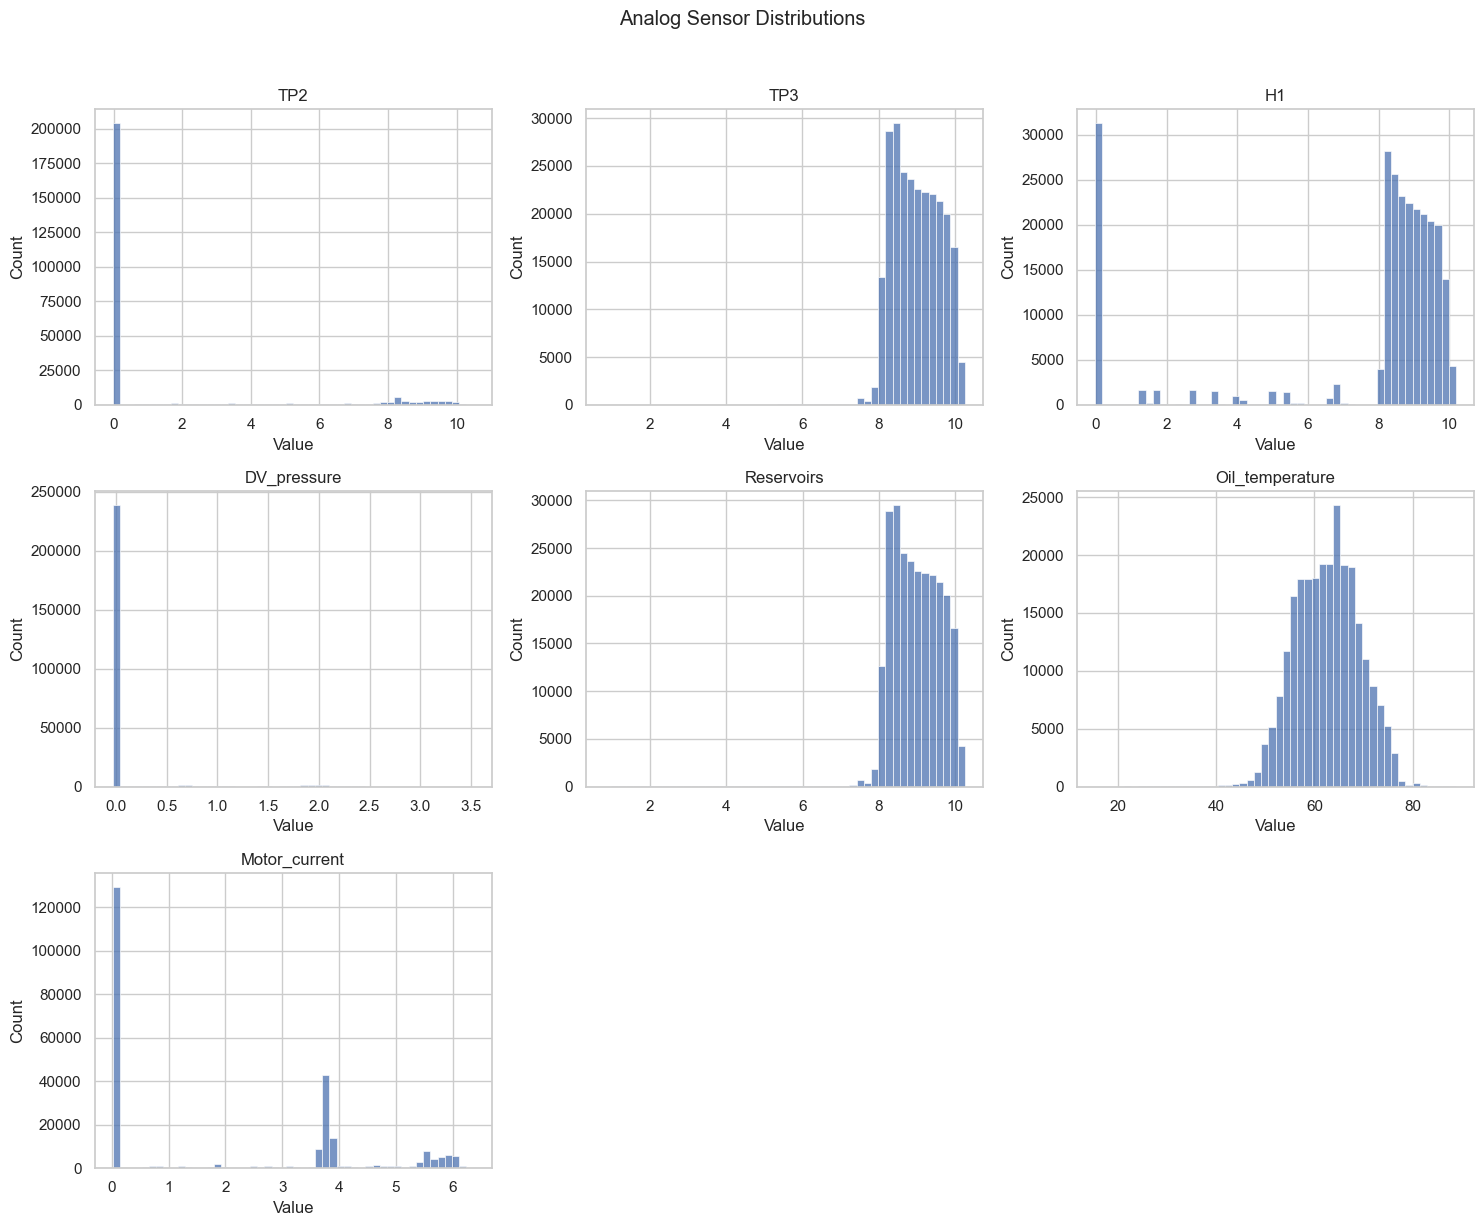

In [32]:
plot_sensor_distributions(
    data=minute_data,
    sensor_columns=ANALOG_SENSOR_COLUMNS,
    bins=50,
    title="Analog Sensor Distributions",
    output_path=FIGURES_DIR / "sensor_distributions.png",
)

## 9. Failure Windows and Helper Labels

The MetroPT-3 dataset is not directly labeled row by row, but the dataset documentation provides known failure windows. These windows are used here to create simple helper labels for analysis.

In [ ]:
failure_windows = pd.DataFrame(FAILURE_WINDOWS)
failure_windows

In [ ]:
labeled_minute_data = add_failure_labels(minute_data)

labeled_minute_data[[
    "timestamp",
    "failure_period",
    "pre_failure_24h",
    "failure_event",
    "operating_state",
]].head()

In [ ]:
operating_state_summary = summarize_operating_states(labeled_minute_data)
operating_state_summary

In [ ]:
failure_event_summary = (
    labeled_minute_data[labeled_minute_data["failure_period"]]
    .groupby("failure_event")
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        records=("timestamp", "count"),
    )
    .reset_index()
)

failure_event_summary

In [ ]:
state_sensor_summary = (
    labeled_minute_data
    .groupby("operating_state")[ANALOG_SENSOR_COLUMNS]
    .mean()
    .round(2)
)

state_sensor_summary

## 10. Sensor Comparison by Operating State

This table compares analog sensor values for normal operation, pre-failure periods, and known failure periods.

In [ ]:
state_sensor_statistics = (
    labeled_minute_data
    .groupby("operating_state")[ANALOG_SENSOR_COLUMNS]
    .agg(["mean", "median", "std"])
    .round(2)
)

state_sensor_statistics

In [ ]:
state_sensor_statistics_tidy = (
    labeled_minute_data
    .groupby("operating_state")[ANALOG_SENSOR_COLUMNS]
    .agg(["mean", "median", "std"])
    .round(2)
    .stack(level=0)
    .reset_index()
    .rename(columns={"level_1": "sensor"})
)

state_sensor_statistics_tidy.head(15)

## 11. Visual Comparison of Operating States

The plots below compare sensor behavior across normal, pre-failure, and failure periods.

In [ ]:
plot_sensor_state_means(
    data=labeled_minute_data,
    sensor_columns=ANALOG_SENSOR_COLUMNS,
    state_column="operating_state",
    title="Mean Analog Sensor Values by Operating State",
    output_path=FIGURES_DIR / "sensor_state_comparison.png",
)

### Oil Temperature with Failure Windows

In [ ]:
plot_sensor_with_failure_windows(
    data=eda_plot_data,
    timestamp_column="timestamp",
    sensor_column="Oil_temperature",
    failure_windows=FAILURE_WINDOWS,
    title="Oil Temperature with Failure Windows",
    output_path=FIGURES_DIR / "oil_temperature_with_failures.png",
)

### Motor Current with Failure Windows

In [ ]:
plot_sensor_with_failure_windows(
    data=eda_plot_data,
    timestamp_column="timestamp",
    sensor_column="Motor_current",
    failure_windows=FAILURE_WINDOWS,
    title="Motor Current with Failure Windows",
    output_path=FIGURES_DIR / "motor_current_with_failures.png",
)

### TP2 and H1 with Failure Windows

In [ ]:
plot_sensor_with_failure_windows(
    data=eda_plot_data,
    timestamp_column="timestamp",
    sensor_column="TP2",
    failure_windows=FAILURE_WINDOWS,
    title="TP2 with Failure Windows",
    output_path=FIGURES_DIR / "tp2_with_failures.png",
)

plot_sensor_with_failure_windows(
    data=eda_plot_data,
    timestamp_column="timestamp",
    sensor_column="H1",
    failure_windows=FAILURE_WINDOWS,
    title="H1 with Failure Windows",
    output_path=FIGURES_DIR / "h1_with_failures.png",
)